Cell 1: modeling table

In [1]:
# Part 3, Cell 1: build the modeling table (self-contained)
import os, re
import numpy as np
import pandas as pd
import geopandas as gpd

RAW, PROC = "data_raw", "data_processed"
seg = gpd.read_file(os.path.join(PROC, "segments_clean.geojson"))
seg["is_ej"] = seg["is_ej"].astype(bool)
seg["yr_built_imputed"] = seg["yr_built_imputed"].astype(bool)
seg["miles"] = seg["length_m"] / 1609.34
seg["units_per_100m"] = seg["res_units"] / (seg["length_m"] / 100)
seg["income_k"] = seg["median_hh_income"].clip(upper=250000) / 1000

# Street-name standardizer (same rules as Part 1) for matching BERDO buildings to streets
SUFFIX = {"AVENUE": "AV", "AVE": "AV", "AV": "AV", "STREET": "ST", "ST": "ST", "ROAD": "RD", "RD": "RD",
          "BOULEVARD": "BL", "BLVD": "BL", "BL": "BL", "PLACE": "PL", "PL": "PL", "TERRACE": "TER",
          "TER": "TER", "TE": "TER", "COURT": "CT", "CT": "CT", "DRIVE": "DR", "DR": "DR", "LANE": "LA",
          "LN": "LA", "LA": "LA", "SQUARE": "SQ", "SQ": "SQ", "PARKWAY": "PKWY", "PKWY": "PKWY", "PW": "PKWY",
          "HIGHWAY": "HWY", "HWY": "HWY", "WAY": "WAY", "WY": "WAY", "CIRCLE": "CIR", "CIR": "CIR",
          "CI": "CIR", "PARK": "PARK", "PK": "PARK", "ROW": "ROW", "WHARF": "WHF", "WHF": "WHF",
          "ALLEY": "AL", "AL": "AL", "HILL": "HL", "HL": "HL"}
DIRS = {"NORTH": "N", "SOUTH": "S", "EAST": "E", "WEST": "W", "N": "N", "S": "S", "E": "E", "W": "W"}

def street_key(*parts):
    text = " ".join(str(p) for p in parts if pd.notna(p) and str(p).strip())
    tokens = re.sub(r"[^A-Z0-9 ]", " ", text.upper()).split()
    if not tokens:
        return None
    tokens = [DIRS.get(t, t) if i in (0, len(tokens) - 1) else t for i, t in enumerate(tokens)]
    for i in range(len(tokens) - 1, 0, -1):
        if tokens[i] in SUFFIX:
            tokens[i] = SUFFIX[tokens[i]]
            break
        if tokens[i] not in DIRS.values():
            break
    return " ".join(tokens)

# Attach BERDO large-building gas use (berdo_clean.csv from Part 2, Cell 11)
seg = seg.drop(columns=[c for c in ["n_large_bldgs", "large_bldg_gas_therms"] if c in seg.columns])
seg["n_large_bldgs"], seg["large_bldg_gas_therms"] = 0, 0.0
berdo_path = os.path.join(PROC, "berdo_clean.csv")
if os.path.exists(berdo_path):
    b = pd.read_csv(berdo_path, dtype={"Tax Parcel ID": str}, low_memory=False)
    n_berdo = len(b)
    b["pid"] = b["Tax Parcel ID"].str.replace(r"\D", "", regex=True).str.zfill(10)
    pa = pd.read_csv(os.path.join(RAW, "boston_property_assessment.csv"), usecols=["PID", "ST_NUM", "ST_NAME"], dtype=str)
    pa["pid"] = pa["PID"].str.replace(r"\D", "", regex=True).str.zfill(10)
    pa["st_num"] = pd.to_numeric(pa["ST_NUM"].str.extract(r"(\d+)")[0], errors="coerce")
    pa["st_key"] = [street_key(s) for s in pa["ST_NAME"]]
    pa = pa.dropna(subset=["st_num", "st_key"]).drop_duplicates("pid")
    b = b.merge(pa[["pid", "st_num", "st_key"]], on="pid", how="inner")

    segr = seg.dropna(subset=["addr_min"])[["seg_id", "st_key", "addr_min", "addr_max"]].sort_values("addr_min")
    m = pd.merge_asof(b.sort_values("st_num"), segr, left_on="st_num", right_on="addr_min",
                      by="st_key", direction="backward")
    m = m[m["st_num"] <= m["addr_max"]]
    agg = m.groupby("seg_id").agg(n_large_bldgs=("pid", "size"), large_bldg_gas_therms=("gas_therms", "sum")).reset_index()
    seg = seg.drop(columns=["n_large_bldgs", "large_bldg_gas_therms"]).merge(agg, on="seg_id", how="left")
    seg[["n_large_bldgs", "large_bldg_gas_therms"]] = seg[["n_large_bldgs", "large_bldg_gas_therms"]].fillna(0)
    print(f"BERDO buildings placed on streets: {len(m):,} of {n_berdo:,} ({len(m) / n_berdo:.0%}), "
          f"{m['gas_therms'].sum() / b['gas_therms'].sum():.0%} of their gas use")
else:
    print("berdo_clean.csv not found (run Part 2, Cell 11); large-building gas set to 0")

seg.to_file(os.path.join(PROC, "model_table.geojson"), driver="GeoJSON")
print(f"\nModeling table: {len(seg):,} street segments, {seg['miles'].sum():,.0f} miles")
seg[["med_yr_built", "units_per_100m", "res_units", "large_bldg_gas_therms", "pct_gas_heat",
     "pct_renter", "income_k", "pct_heat_pump"]].describe().round(2)

BERDO buildings placed on streets: 4,523 of 5,578 (81%), 91% of their gas use

Modeling table: 17,820 street segments, 1,032 miles


,med_yr_built,units_per_100m,res_units,large_bldg_gas_therms,pct_gas_heat,pct_renter,income_k,pct_heat_pump
count,17820.00,17820.00,17820.00,17820.00,17820.00,17820.00,17820.00,17820.00
mean,1923.94,13.09,11.73,4928.80,0.60,0.59,115.91,0.00
std,30.43,31.76,23.75,72472.69,0.20,0.26,56.07,0.05
min,1752.00,0.00,0.00,0.00,0.00,0.00,2.50,0.00
25%,1903.00,0.00,0.00,0.00,0.48,0.39,74.94,0.00
50%,1915.00,5.42,3.00,0.00,0.62,0.62,109.06,0.00
75%,1935.00,16.40,14.00,0.00,0.73,0.81,144.90,0.00
max,2025.00,2483.79,525.00,8409212.75,1.00,1.00,250.00,1.00


Cell 2: street archetypes (unsupervised machine learning)

Silhouette by k: {3: 0.218, 4: 0.228, 5: 0.218, 6: 0.23, 7: 0.214, 8: 0.213} -> using k = 6


,Building year,Gas heat share,Renter share,Income ($k),Heat pump share,street_miles,ej_share,Housing units per 100 m,Large-building gas (therms)
archetype,,,,,,,,,
0,1980.84,0.59,0.57,109.09,0.00,122.76,0.84,2.82,0.02
1,1918.04,0.71,0.30,168.08,0.00,268.86,0.57,4.29,0.02
2,1915.21,0.49,0.77,91.41,0.00,243.50,0.85,0.11,0.00
3,1909.01,0.63,0.66,93.45,0.00,275.86,0.90,18.94,0.01
4,1952.93,0.49,0.54,140.42,0.74,3.08,0.53,34.05,11.33
5,1933.49,0.52,0.69,109.70,0.01,117.66,0.84,8.82,21332.66


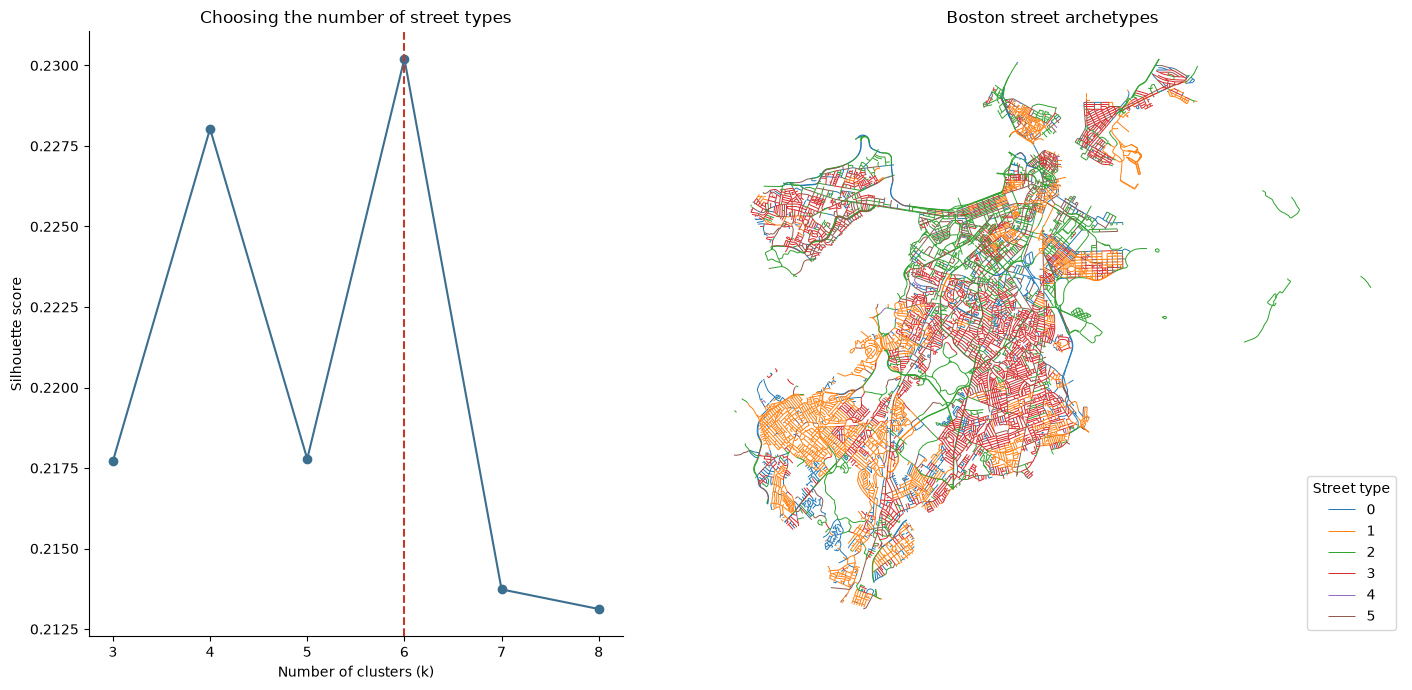

In [2]:
# Part 3, Cell 2: group streets into archetypes with k-means (self-contained; reads Cell 1 output)
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

PROC, FIG = "data_processed", "figures"
os.makedirs(FIG, exist_ok=True)
seg = gpd.read_file(os.path.join(PROC, "model_table.geojson"))
seg["is_ej"] = seg["is_ej"].astype(bool)

feat = pd.DataFrame({
    "Building year": seg["med_yr_built"],
    "Housing units per 100 m (log)": np.log1p(seg["units_per_100m"]),
    "Large-building gas (log therms)": np.log1p(seg["large_bldg_gas_therms"]),
    "Gas heat share": seg["pct_gas_heat"],
    "Renter share": seg["pct_renter"],
    "Income ($k)": seg["income_k"],
    "Heat pump share": seg["pct_heat_pump"],
})
Xs = StandardScaler().fit_transform(feat.fillna(feat.median()))

# Pick the number of clusters with the silhouette score (higher = better-separated groups)
idx = np.random.default_rng(42).choice(len(Xs), min(5000, len(Xs)), replace=False)
sil = {}
for k in range(3, 9):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xs)
    sil[k] = silhouette_score(Xs[idx], labels[idx])
best_k = max(sil, key=sil.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in sil.items()}, "-> using k =", best_k)

km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(Xs)
seg["archetype"] = km.labels_

profile = (feat.assign(archetype=km.labels_, miles=seg["miles"], ej=seg["is_ej"])
               .groupby("archetype")
               .agg(**{c: (c, "mean") for c in feat.columns},
                    street_miles=("miles", "sum"), ej_share=("ej", "mean")))
profile["Housing units per 100 m"] = np.expm1(profile.pop("Housing units per 100 m (log)"))
profile["Large-building gas (therms)"] = np.expm1(profile.pop("Large-building gas (log therms)"))
display(profile.round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1, 1.6]})
ax[0].plot(list(sil), list(sil.values()), marker="o", color="#3b6e8f")
ax[0].axvline(best_k, color="#c0392b", linestyle="--")
ax[0].set(title="Choosing the number of street types", xlabel="Number of clusters (k)", ylabel="Silhouette score")
ax[0].spines[["top", "right"]].set_visible(False)
seg.plot(ax=ax[1], column="archetype", categorical=True, cmap="tab10", linewidth=0.7, legend=True,
         legend_kwds={"title": "Street type", "loc": "lower right"})
ax[1].set_title("Boston street archetypes"); ax[1].set_axis_off()
plt.tight_layout(); fig.savefig(os.path.join(FIG, "13_street_archetypes.png"), bbox_inches="tight"); plt.show()

seg.to_file(os.path.join(PROC, "model_table.geojson"), driver="GeoJSON")

Cell 3: leak-prone risk (supervised model when leak data exists; provisional score until then)

In [3]:
# Part 3, Cell 3: leak-prone risk score (self-contained; reads Cell 2 output)
import os, re
import numpy as np
import pandas as pd
import geopandas as gpd
import requests

RAW, PROC = "data_raw", "data_processed"
seg = gpd.read_file(os.path.join(PROC, "model_table.geojson"))
seg["yr_built_imputed"] = seg["yr_built_imputed"].astype(bool)
FEATS = ["med_yr_built", "units_per_100m", "res_units", "large_bldg_gas_therms", "length_m",
         "pct_gas_heat", "pct_pre1940", "pct_renter", "income_k", "pct_heat_pump"]
LABELS = os.path.join(PROC, "leaks_by_segment.csv")   # expected columns: seg_id, year, n_leaks

if os.path.exists(LABELS):
    # ---- Supervised model: predict whether a street has a leak next year ----
    from sklearn.ensemble import HistGradientBoostingClassifier
    from sklearn.metrics import roc_auc_score, average_precision_score

    lk = pd.read_csv(LABELS)
    years = sorted(lk["year"].unique())
    counts = lk.pivot_table(index="seg_id", columns="year", values="n_leaks", aggfunc="sum").reindex(seg["seg_id"]).fillna(0)

    def panel(t):
        X = seg.set_index("seg_id")[FEATS].copy()
        X["leaks_last_1y"] = counts[t].values
        X["leaks_last_3y"] = counts[[y for y in years if t - 2 <= y <= t]].sum(axis=1).values
        X["leaks_ever"] = counts[[y for y in years if y <= t]].sum(axis=1).values
        return X

    rows = [(panel(t), (counts[t + 1] > 0).astype(int).values) for t in years[:-1] if t + 1 in years]
    X_train = pd.concat([r[0] for r in rows[:-1]]); y_train = np.concatenate([r[1] for r in rows[:-1]])
    X_test, y_test = rows[-1]
    model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42).fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]

    top = np.argsort(-p)[: int(len(p) * 0.10)]
    print(f"Held-out year {years[-1]}: ROC-AUC {roc_auc_score(y_test, p):.3f} | "
          f"PR-AUC {average_precision_score(y_test, p):.3f} (base rate {y_test.mean():.3f}) | "
          f"top 10% of streets catch {y_test[top].sum() / max(y_test.sum(), 1):.0%} of leaking streets")

    full = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42)
    full.fit(pd.concat([X_train, X_test]), np.concatenate([y_train, y_test]))
    seg["risk_score"] = full.predict_proba(panel(years[-1]))[:, 1]
    seg["risk_source"] = "Gradient boosting model trained on leak records"
    seg["likely_leak_prone"] = seg["risk_score"] >= seg["risk_score"].quantile(0.66)

else:
    # ---- Provisional score until leak records are available ----
    # Mains were usually laid when a street was built up, so older streets are more likely to have
    # cast-iron or unprotected steel. Calibrate the flagged share to Boston Gas's leak-prone share in DPU's report.
    pdf = os.path.join(RAW, "dpu_25_glr_01.pdf")
    if not os.path.exists(pdf):
        r = requests.get("https://malegislature.gov/Bills/194/SD3561.pdf", timeout=120, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status(); open(pdf, "wb").write(r.content)
    from pypdf import PdfReader
    flat = re.sub(r"\s+", " ", " ".join(pg.extract_text() or "" for pg in PdfReader(pdf).pages))
    mt = re.search(r"For Boston Gas, National Grid states.*?thus,\s*approximately (\d+(?:\.\d+)?) percent of the "
                   r"distribution system mains consist of leak-prone pipe", flat)
    if not mt:
        raise ValueError("Could not find Boston Gas's leak-prone share in the DPU report")
    share = float(mt.group(1)) / 100
    print(f"Calibration from DPU report: Boston Gas leak-prone share of mains = {share:.0%}")

    age_rank = seg["med_yr_built"].rank(pct=True, ascending=False)            # older -> closer to 1
    seg["risk_score"] = age_rank * np.where(seg["yr_built_imputed"], 0.9, 1.0)  # slightly less confident if age was borrowed
    order = seg["risk_score"].sort_values(ascending=False).index
    cum_share = seg.loc[order, "miles"].cumsum() / seg["miles"].sum()
    seg["likely_leak_prone"] = False
    seg.loc[order[cum_share <= share], "likely_leak_prone"] = True
    seg["risk_source"] = "Provisional: building-age score calibrated to DPU's Boston Gas leak-prone share"
    print("PROVISIONAL risk score: add data_processed/leaks_by_segment.csv to switch to the trained model.")

flagged = seg[seg["likely_leak_prone"]]
print(f"\nStreets flagged likely leak-prone: {len(flagged):,} segments, {flagged['miles'].sum():,.0f} miles "
      f"({flagged['miles'].sum() / seg['miles'].sum():.0%} of street miles)")
print(f"Median building year, flagged vs not: {flagged['med_yr_built'].median():.0f} vs "
      f"{seg.loc[~seg['likely_leak_prone'], 'med_yr_built'].median():.0f}")
display(seg.groupby("archetype").agg(miles=("miles", "sum"), flagged_share=("likely_leak_prone", "mean")).round(2))

seg.to_file(os.path.join(PROC, "model_scored.geojson"), driver="GeoJSON")

Calibration from DPU report: Boston Gas leak-prone share of mains = 34%
PROVISIONAL risk score: add data_processed/leaks_by_segment.csv to switch to the trained model.

Streets flagged likely leak-prone: 6,348 segments, 351 miles (34% of street miles)
Median building year, flagged vs not: 1900 vs 1927


,miles,flagged_share
archetype,,
0,122.76,0.00
1,268.86,0.34
2,243.50,0.34
3,275.86,0.56
4,3.08,0.29
5,117.66,0.32


Cell 4: replace or electrify? Costs and a budget-limited plan

Replacement cost per mile (2024 actual, statewide, incl. services): $3.06M
Could not read the working group ratio; lifetime ratepayer cost will equal capital cost. 403 Client Error: Forbidden for url: https://www.mass.gov/doc/october-20-2023-gsep-working-group-approved-meeting-minutes/download

Breakeven density: 139 housing units per mile (8.6 per 100 m). Below this, electrifying costs less than new pipe.
Flagged streets: 351 miles | electrify: 35 miles, 2,787 homes
Capital cost, replace everything: $1.07B  vs  mixed plan: $1.03B (saves 4%)
Lifetime ratepayer cost, replace everything: $1.07B  vs  mixed plan: $1.03B
At $100M per year: about 11 years to address all flagged streets
Share of electrified miles in EJ block groups: 78%


,hp_cost_per_unit,electrified_miles,savings_vs_replace
0,15000,59.458,0.071
1,22000,34.680,0.042
2,30000,23.072,0.027
3,40000,15.438,0.018


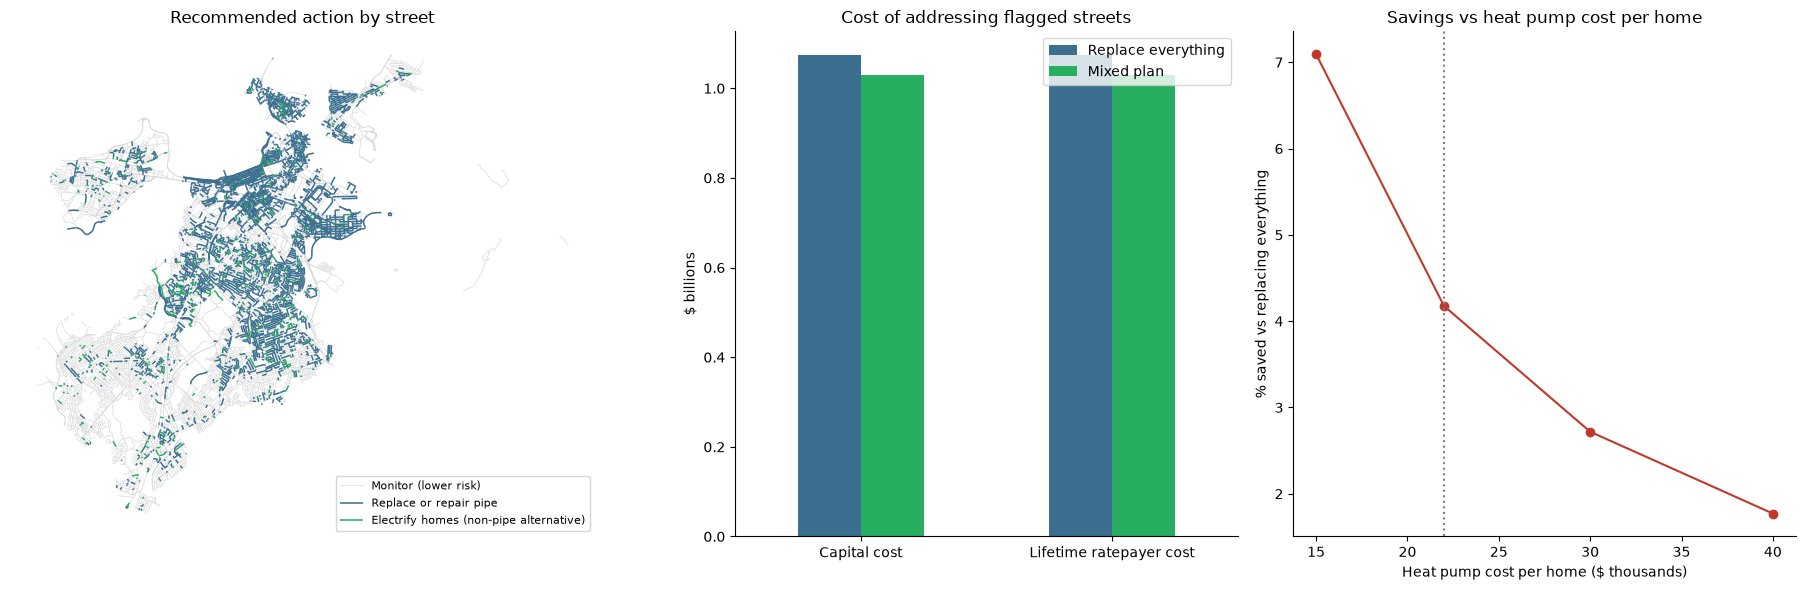


Saved segments_scored.geojson and plan_summary.json for the app


In [4]:
# Part 3, Cell 4: triage each flagged street and build a budget schedule (self-contained; reads Cell 3 output)
import os, re, json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests

RAW, PROC, FIG = "data_raw", "data_processed", "figures"
seg = gpd.read_file(os.path.join(PROC, "model_scored.geojson"))
for c in ["likely_leak_prone", "is_ej"]:
    seg[c] = seg[c].astype(bool)

# --- Cost inputs ---
# 1) Pipe replacement cost per mile: latest actual year from DPU's report (gsep_annual.csv from Part 2, Cell 12)
gsep = pd.read_csv(os.path.join(PROC, "gsep_annual.csv")).sort_values("year")
latest = gsep.iloc[-1]
COST_PER_MILE = latest["spend_musd"] * 1e6 / latest["main_miles"]
print(f"Replacement cost per mile ({int(latest['year'])} actual, statewide, incl. services): ${COST_PER_MILE / 1e6:.2f}M")

# 2) Lifetime ratepayer cost per $1 of GSEP capital: DPU GSEP Working Group minutes (Oct 20, 2023)
WG_URL = "https://www.mass.gov/doc/october-20-2023-gsep-working-group-approved-meeting-minutes/download"
wg = os.path.join(RAW, "gsep_wg_2023_10_20.pdf")
MULT = 1.0
try:
    if not os.path.exists(wg):
        r = requests.get(WG_URL, timeout=120, headers={"User-Agent": "Mozilla/5.0"}); r.raise_for_status()
        open(wg, "wb").write(r.content)
    from pypdf import PdfReader
    wtxt = re.sub(r"\s+", " ", " ".join(pg.extract_text() or "" for pg in PdfReader(wg).pages))
    capex = re.search(r"capital expenditures from 2022 through 2039 was \$([\d.]+) billion", wtxt)
    cost = re.search(r"cost to ratepayers was \$([\d.]+) billion", wtxt)
    MULT = float(cost.group(1)) / float(capex.group(1))
    print(f"Ratepayer cost per $1 of GSEP capital (DPU working group): ${MULT:.2f}")
except Exception as e:
    print("Could not read the working group ratio; lifetime ratepayer cost will equal capital cost.", e)

# 3) Electrification cost per housing unit: ASSUMPTION, tested below.
#    Mass Save program data put a typical whole-home air-source heat pump install near $22,000.
HP_COST_PER_UNIT = 22_000
ANNUAL_BUDGET = 100e6   # ASSUMPTION: annual Boston budget for leak-prone streets; change to test scenarios

# --- Triage each flagged street ---
s = seg[seg["likely_leak_prone"]].copy()
s["replace_cost"] = s["miles"] * COST_PER_MILE
s["electrify_cost"] = s["res_units"] * HP_COST_PER_UNIT
s["npa_eligible"] = (s["n_large_bldgs"] == 0) & (s["res_units"] > 0)   # no large BERDO buildings, has homes
s["electrify"] = s["npa_eligible"] & (s["electrify_cost"] < s["replace_cost"])
s["action"] = np.where(s["electrify"], "Electrify homes (non-pipe alternative)", "Replace or repair pipe")
s["action_cost"] = np.where(s["electrify"], s["electrify_cost"], s["replace_cost"])
s["ratepayer_cost"] = np.where(s["electrify"], s["electrify_cost"], s["replace_cost"] * MULT)

# Priority: risk-weighted miles addressed per dollar; schedule within the annual budget
s["priority"] = s["risk_score"] * s["miles"] / s["action_cost"].clip(lower=1)
s = s.sort_values("priority", ascending=False)
s["plan_year"] = (s["action_cost"].cumsum() // ANNUAL_BUDGET).astype(int) + 1

seg["action"] = "Monitor (lower risk)"
seg["plan_year"] = np.nan
for c in ["replace_cost", "electrify_cost", "action_cost", "ratepayer_cost", "priority"]:
    seg[c] = np.nan
seg.loc[s.index, ["action", "plan_year", "replace_cost", "electrify_cost", "action_cost", "ratepayer_cost", "priority"]] = \
    s[["action", "plan_year", "replace_cost", "electrify_cost", "action_cost", "ratepayer_cost", "priority"]]

# --- Results ---
breakeven = COST_PER_MILE / HP_COST_PER_UNIT
all_replace = s["replace_cost"].sum()
mixed = s["action_cost"].sum()
el = s[s["electrify"]]
summary = {
    "risk_source": seg["risk_source"].iloc[0],
    "cost_per_mile_usd": COST_PER_MILE, "cost_year": int(latest["year"]),
    "ratepayer_multiplier": MULT, "hp_cost_per_unit_usd": HP_COST_PER_UNIT, "annual_budget_usd": ANNUAL_BUDGET,
    "flagged_miles": float(s["miles"].sum()), "electrify_miles": float(el["miles"].sum()),
    "electrify_units": float(el["res_units"].sum()),
    "all_replace_capital_usd": float(all_replace), "mixed_capital_usd": float(mixed),
    "all_replace_ratepayer_usd": float(all_replace * MULT), "mixed_ratepayer_usd": float(s["ratepayer_cost"].sum()),
    "years_to_finish": int(s["plan_year"].max()),
    "ej_share_of_electrified_miles": float((el["miles"] * el["is_ej"]).sum() / max(el["miles"].sum(), 1e-9)),
}
print(f"\nBreakeven density: {breakeven:,.0f} housing units per mile ({breakeven / 16.09:.1f} per 100 m). "
      f"Below this, electrifying costs less than new pipe.")
print(f"Flagged streets: {summary['flagged_miles']:,.0f} miles | electrify: {summary['electrify_miles']:,.0f} miles, "
      f"{summary['electrify_units']:,.0f} homes")
print(f"Capital cost, replace everything: ${all_replace / 1e9:,.2f}B  vs  mixed plan: ${mixed / 1e9:,.2f}B "
      f"(saves {1 - mixed / all_replace:.0%})")
print(f"Lifetime ratepayer cost, replace everything: ${summary['all_replace_ratepayer_usd'] / 1e9:,.2f}B  vs  "
      f"mixed plan: ${summary['mixed_ratepayer_usd'] / 1e9:,.2f}B")
print(f"At ${ANNUAL_BUDGET / 1e6:,.0f}M per year: about {summary['years_to_finish']} years to address all flagged streets")
print(f"Share of electrified miles in EJ block groups: {summary['ej_share_of_electrified_miles']:.0%}")

# Sensitivity to the heat pump cost assumption
sens = []
for hp in [15_000, 22_000, 30_000, 40_000]:
    e = s["npa_eligible"] & (s["res_units"] * hp < s["replace_cost"])
    cost = np.where(e, s["res_units"] * hp, s["replace_cost"]).sum()
    sens.append({"hp_cost_per_unit": hp, "electrified_miles": s.loc[e, "miles"].sum(), "savings_vs_replace": 1 - cost / all_replace})
sens = pd.DataFrame(sens)
display(sens.round(3))

# Charts
fig, ax = plt.subplots(1, 3, figsize=(19, 6), gridspec_kw={"width_ratios": [1.5, 1, 1]})
colors = {"Monitor (lower risk)": "#d9d9d9", "Replace or repair pipe": "#3b6e8f",
          "Electrify homes (non-pipe alternative)": "#27ae60"}
for act, col in colors.items():
    seg[seg["action"] == act].plot(ax=ax[0], color=col, linewidth=0.5 if act.startswith("Monitor") else 1.1, label=act)
ax[0].legend(loc="lower right", fontsize=8); ax[0].set_title("Recommended action by street"); ax[0].set_axis_off()

bars = pd.DataFrame({"Replace everything": [all_replace, all_replace * MULT],
                     "Mixed plan": [mixed, s["ratepayer_cost"].sum()]},
                    index=["Capital cost", "Lifetime ratepayer cost"]) / 1e9
bars.plot.bar(ax=ax[1], color=["#3b6e8f", "#27ae60"], rot=0)
ax[1].set(title="Cost of addressing flagged streets", ylabel="$ billions")

ax[2].plot(sens["hp_cost_per_unit"] / 1000, sens["savings_vs_replace"] * 100, marker="o", color="#c0392b")
ax[2].axvline(HP_COST_PER_UNIT / 1000, color="grey", linestyle=":")
ax[2].set(title="Savings vs heat pump cost per home", xlabel="Heat pump cost per home ($ thousands)",
          ylabel="% saved vs replacing everything")
for a in ax[1:]:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); fig.savefig(os.path.join(FIG, "14_triage_plan.png"), bbox_inches="tight"); plt.show()

# Save outputs for the Streamlit app (Part 4)
out = seg.to_crs(4326).copy()
out["geometry"] = out.geometry.simplify(0.00003)
out.to_file(os.path.join(PROC, "segments_scored.geojson"), driver="GeoJSON")
json.dump(summary, open(os.path.join(PROC, "plan_summary.json"), "w"), indent=2)
print("\nSaved segments_scored.geojson and plan_summary.json for the app")

# What this tells us?

The headline: in most of old Boston, new pipe is still cheaper than switching homes to heat pumps.

1. Where the old pipe likely is. The model flags about 351 miles of Boston streets as likely leak-prone, the oldest streets calibrated to Boston Gas's share of leak-prone mains in DPU's report. Replacing all of it at the latest statewide cost of $3.06 million per mile would cost about $1.07 billion in capital.

2. The tipping point is 8.6 homes per 100 meters of street. At about $22,000 per home for a heat pump, electrifying every home on a street costs less than new pipe only when the street has fewer than about 139 homes per mile. That's the project's most useful single number, because any planner can apply it to any street.

3. Few old streets fall below that tipping point. Only 35 of the 351 miles (about 2,800 homes) are cheaper to electrify. The rest are mostly dense triple-decker and rental neighborhoods with around 19 homes per 100 m, more than double the tipping point. So the mixed plan saves only about 4% compared with replacing everything.

4. Who's affected. 78% of the streets where electrification wins are in environmental-justice neighborhoods. Any program there would need income-qualified support and protections for renters, who don't control their landlord's heating system.

5. How long it takes. At an assumed $100 million a year, addressing all flagged streets takes about 11 years. That's driven entirely by the budget assumption.

6. How sensitive this is. If heat pumps cost 15,000USD per home, savings rise to about 7%. At 40,000USD, they fall to about 2%. In no case does house-by-house electrification transform the picture.

What it means

House-by-house heat pumps aren't the answer for dense old Boston. The realistic alternative there is shared systems like networked geothermal, where one loop serves many units and spreads the cost. That's why National Grid kept the Franklin Field pilot in Dorchester, serving multifamily public housing. A strong next step for the project is to model networked geothermal as a third option for dense streets.

Three caveats to state honestly

The leak risk is provisional. It's based on building age until real leak records are added.
The lifetime-cost comparison may shift things. Once the DPU ratepayer ratio loads (about $2.16 paid per $1 of capital), pipe's true cost to customers roughly doubles, which would pull more streets toward electrification. Heat pumps needing replacement every 15 to 20 years pushes the other way.
The network effect is missing. Removing gas from one street can affect neighboring streets, which this model can't see. That's one reason the utilities rejected all 500 alternative projects they reviewed for 2026.